In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("../data/processed/cleaned_tickets.csv")

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [35]:
print("Shape:", df.shape)
df.head()

Shape: (1404, 28)


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating,is_closed,is_open,resolution_time_hours,response_delay_hours,is_delayed,customer_effort_score,high_effort,priority_score,description_length,resolution_length,ticket_type_grouped
0,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,True,False,6.850000,25259.243889,False,0.685000,False,1,275,44,Technical issue
1,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,True,False,19.683333,29112.211667,True,2.968333,True,1,333,27,Billing inquiry
2,20,Jeffrey Robertson,jameslopez@example.com,39,Female,Canon EOS,2021-03-08,Refund request,Software bug,I'm having an issue with the {product_purchase...,Closed,Wish mouth build resource though.,Low,Chat,2023-06-01 00:46:04,2023-06-01 20:29:04,5.0,True,False,19.716667,19560.767778,True,2.971667,True,1,292,33,Refund request
3,29,Christine Wang,garciastacy@example.com,30,Other,Fitbit Charge,2020-06-10,Technical issue,Product recommendation,I'm having an issue with the {product_purchase...,Closed,Soldier we such inside.,Critical,Phone,2023-05-31 23:17:17,2023-06-01 06:03:17,5.0,True,False,6.766667,26063.288056,False,0.676667,False,4,334,23,Technical issue
4,30,Austin George,shericase@example.net,67,Male,Xbox,2020-12-26,Cancellation request,Cancellation request,I'm having an issue with the {product_purchase...,Closed,Firm sort voice above which site arrive.,Medium,Phone,2023-06-01 00:54:17,2023-06-01 18:23:17,1.0,True,False,17.483333,21288.904722,True,2.748333,True,2,203,40,Cancellation request


In [36]:
print(df.columns.tolist())
print("\nMissing values:\n")
print(df.isnull().sum())

['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating', 'is_closed', 'is_open', 'resolution_time_hours', 'response_delay_hours', 'is_delayed', 'customer_effort_score', 'high_effort', 'priority_score', 'description_length', 'resolution_length', 'ticket_type_grouped']

Missing values:

ticket_id                       0
customer_name                   0
customer_email                  0
customer_age                    0
customer_gender                 0
product_purchased               0
date_of_purchase                0
ticket_type                     0
ticket_subject                  0
ticket_description              0
ticket_status                   0
resolution                      0
ticket_priority                 0
tick

In [37]:
total_tickets = len(df)
avg_resolution = df["resolution_time_hours"].mean()
median_resolution = df["resolution_time_hours"].median()
avg_response_delay = df["response_delay_hours"].mean()
delay_rate = df["is_delayed"].mean() * 100
avg_satisfaction = df["customer_satisfaction_rating"].mean()
high_effort_rate = df["high_effort"].mean() * 100

print(f"Total analyzed tickets: {total_tickets:,}")
print(f"Average resolution time (hours): {avg_resolution:.2f}")
print(f"Median resolution time (hours): {median_resolution:.2f}")
print(f"Average response delay (hours): {avg_response_delay:.2f}")
print(f"Delay rate: {delay_rate:.2f}%")
print(f"Average customer satisfaction: {avg_satisfaction:.2f} / 5")
print(f"High-effort ticket rate: {high_effort_rate:.2f}%")

Total analyzed tickets: 1,404
Average resolution time (hours): 7.58
Median resolution time (hours): 6.34
Average response delay (hours): 21244.82
Delay rate: 25.00%
Average customer satisfaction: 3.03 / 5
High-effort ticket rate: 25.00%


D:\ana\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


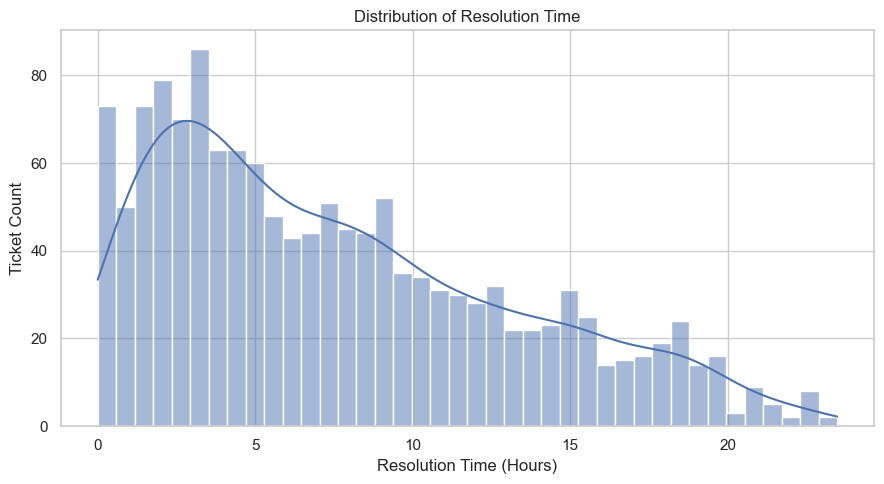

In [38]:
plt.figure(figsize=(9, 5))
sns.histplot(df["resolution_time_hours"], bins=40, kde=True)
plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Ticket Count")
plt.tight_layout()
plt.show()

D:\ana\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


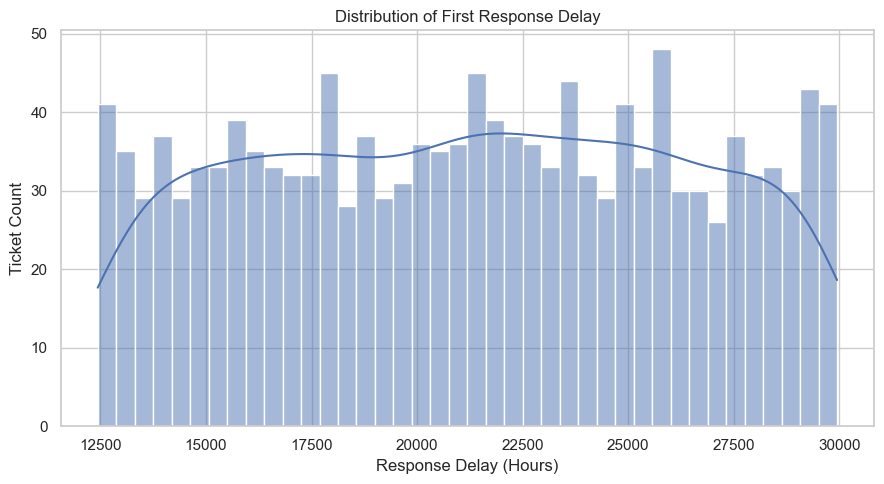

In [39]:
plt.figure(figsize=(9, 5))
sns.histplot(df["response_delay_hours"].dropna(), bins=40, kde=True)
plt.title("Distribution of First Response Delay")
plt.xlabel("Response Delay (Hours)")
plt.ylabel("Ticket Count")
plt.tight_layout()
plt.show()

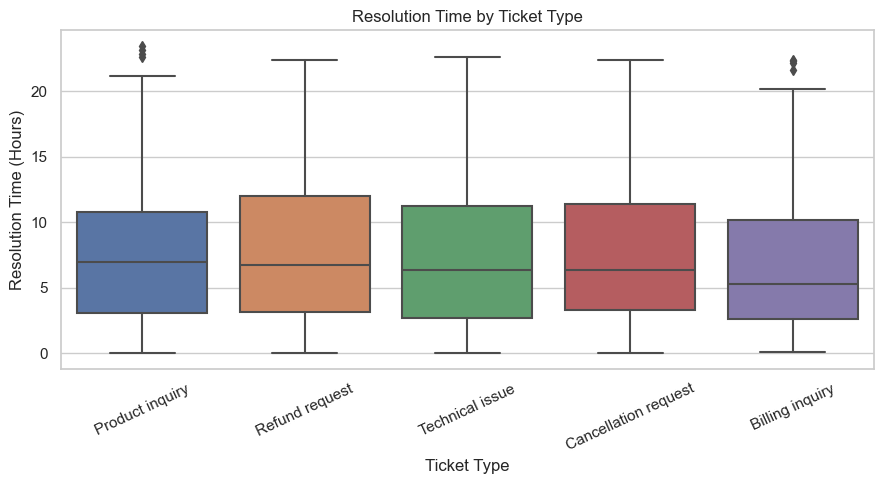

In [40]:
ticket_type_order = (
    df.groupby("ticket_type_grouped")["resolution_time_hours"]
      .median()
      .sort_values(ascending=False)
      .index
)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="ticket_type_grouped",
    y="resolution_time_hours",
    order=ticket_type_order
)
plt.title("Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Resolution Time (Hours)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

ticket_type_grouped
Refund request          8.117818
Cancellation request    7.693082
Product inquiry         7.676070
Technical issue         7.365191
Billing inquiry         7.010256
Name: resolution_time_hours, dtype: float64


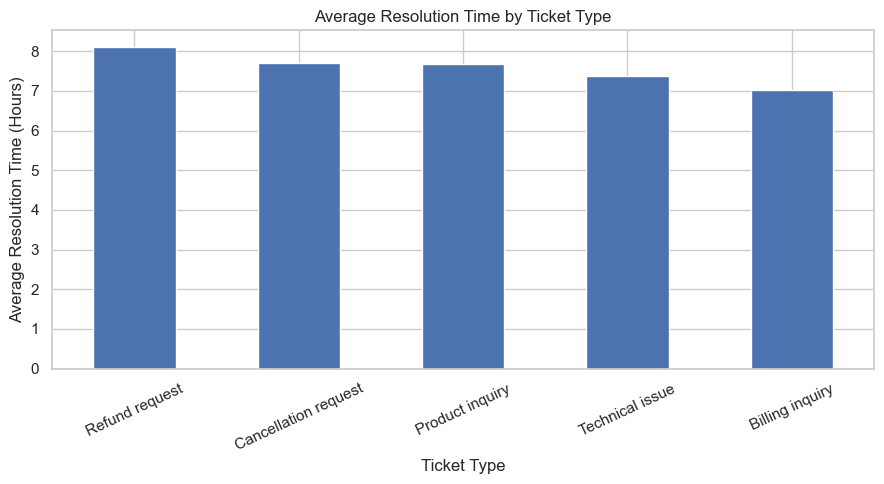

In [41]:
resolution_by_type = (
    df.groupby("ticket_type_grouped")["resolution_time_hours"]
      .mean()
      .sort_values(ascending=False)
)

print(resolution_by_type)

plt.figure(figsize=(9, 5))
resolution_by_type.plot(kind="bar")
plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

ticket_type_grouped
Refund request          0.286184
Cancellation request    0.252830
Technical issue         0.249180
Product inquiry         0.249027
Billing inquiry         0.208791
Name: is_delayed, dtype: float64


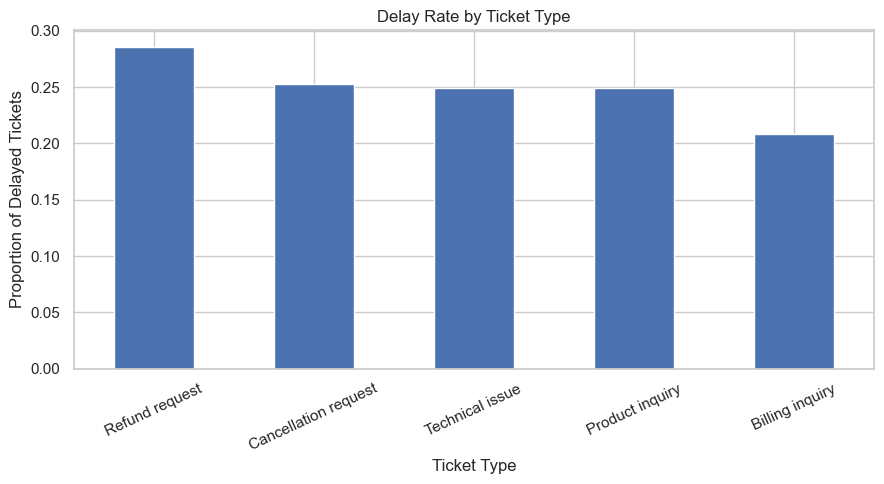

In [42]:
delay_by_type = (
    df.groupby("ticket_type_grouped")["is_delayed"]
      .mean()
      .sort_values(ascending=False)
)

print(delay_by_type)

plt.figure(figsize=(9, 5))
delay_by_type.plot(kind="bar")
plt.title("Delay Rate by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Proportion of Delayed Tickets")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

ticket_type_grouped
Technical issue         2.891803
Refund request          2.898026
Cancellation request    3.120755
Billing inquiry         3.135531
Product inquiry         3.136187
Name: customer_satisfaction_rating, dtype: float64


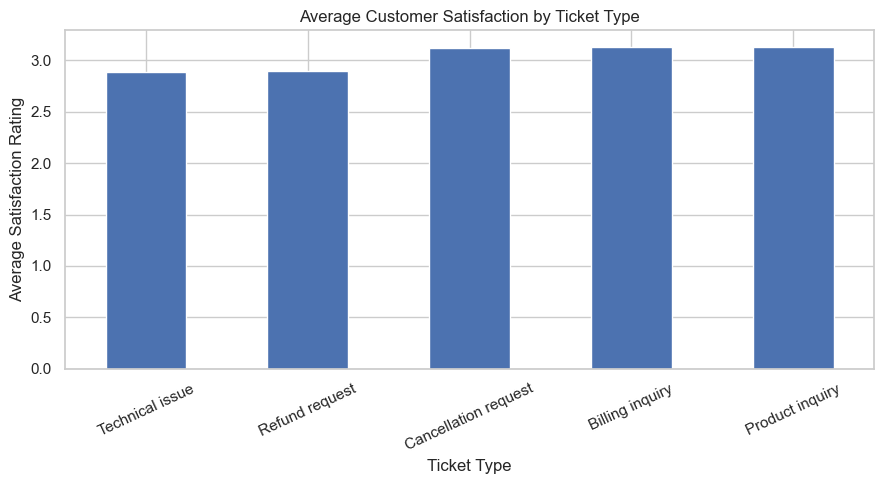

In [43]:
satisfaction_by_type = (
    df.groupby("ticket_type_grouped")["customer_satisfaction_rating"]
      .mean()
      .sort_values()
)

print(satisfaction_by_type)

plt.figure(figsize=(9, 5))
satisfaction_by_type.plot(kind="bar")
plt.title("Average Customer Satisfaction by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Average Satisfaction Rating")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

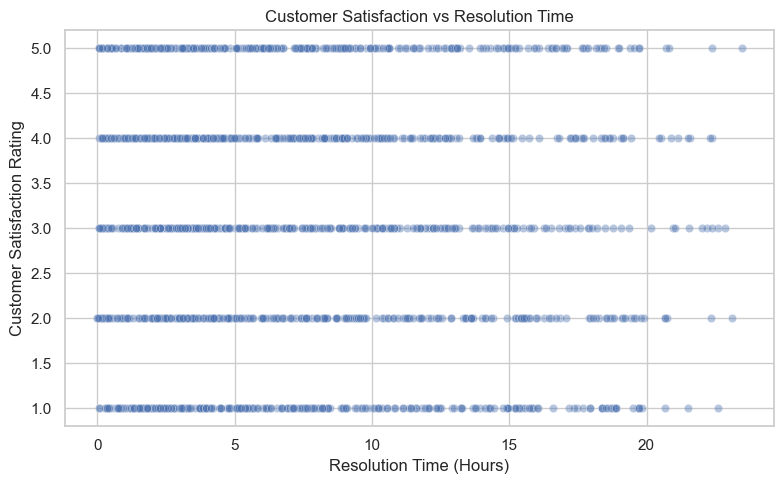

In [44]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="resolution_time_hours",
    y="customer_satisfaction_rating",
    alpha=0.4
)
plt.title("Customer Satisfaction vs Resolution Time")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Customer Satisfaction Rating")
plt.tight_layout()
plt.show()

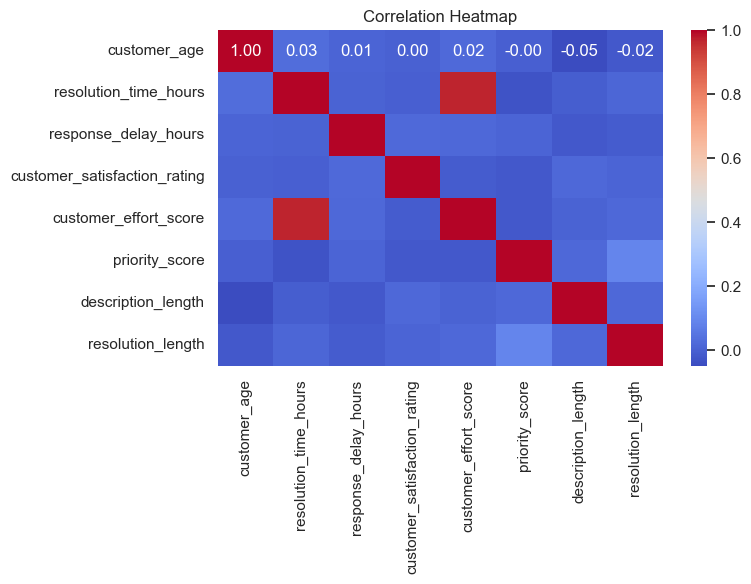

In [45]:
numeric_cols = [
    "customer_age",
    "resolution_time_hours",
    "response_delay_hours",
    "customer_satisfaction_rating",
    "customer_effort_score",
    "priority_score",
    "description_length",
    "resolution_length"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [46]:
channel_summary = (
    df.groupby("ticket_channel")
      .agg(
          ticket_count=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          avg_response_delay_hours=("response_delay_hours", "mean"),
          avg_satisfaction=("customer_satisfaction_rating", "mean"),
          delay_rate=("is_delayed", "mean"),
          high_effort_rate=("high_effort", "mean")
      )
      .sort_values(by="avg_resolution_hours", ascending=False)
)

channel_summary

,ticket_count,avg_resolution_hours,avg_response_delay_hours,avg_satisfaction,delay_rate,high_effort_rate
ticket_channel,,,,,,
Social media,348,7.911734,20784.829385,3.034483,0.267241,0.267241
Email,374,7.617781,21642.043539,2.965241,0.251337,0.251337
Chat,355,7.497793,20989.558694,3.185915,0.250704,0.250704
Phone,327,7.264118,21557.133243,2.923547,0.229358,0.229358


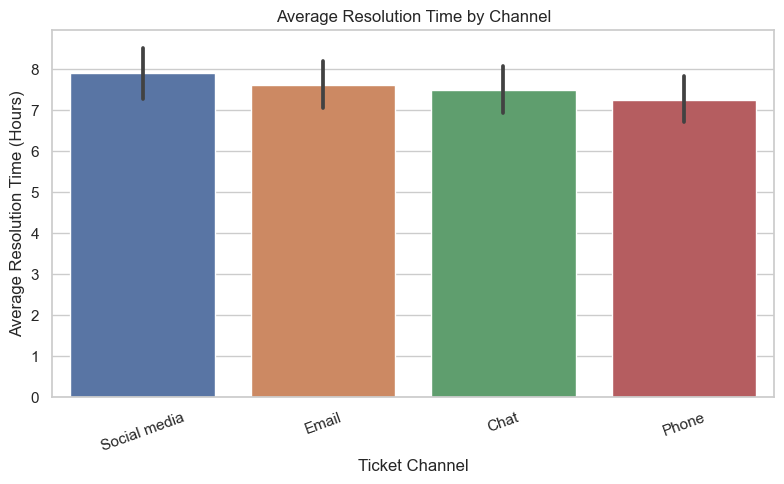

In [47]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="ticket_channel",
    y="resolution_time_hours",
    estimator=np.mean
)
plt.title("Average Resolution Time by Channel")
plt.xlabel("Ticket Channel")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

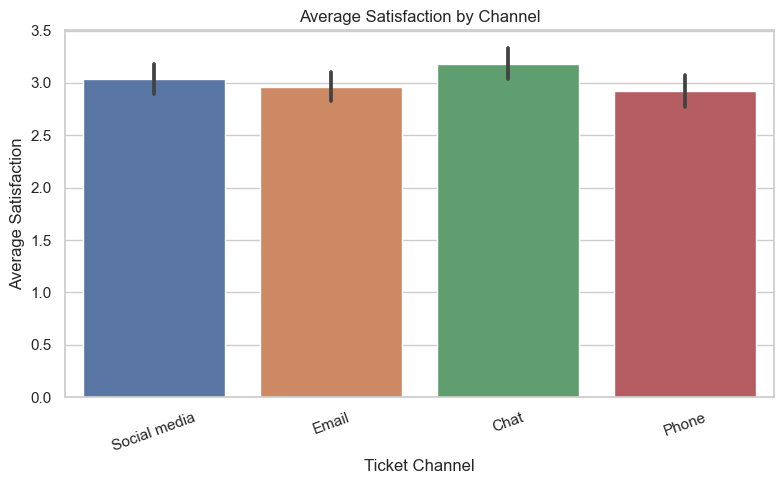

In [48]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x="ticket_channel",
    y="customer_satisfaction_rating",
    estimator=np.mean
)
plt.title("Average Satisfaction by Channel")
plt.xlabel("Ticket Channel")
plt.ylabel("Average Satisfaction")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [49]:
priority_summary = (
    df.groupby("ticket_priority")
      .agg(
          ticket_count=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          avg_satisfaction=("customer_satisfaction_rating", "mean"),
          delay_rate=("is_delayed", "mean")
      )
      .sort_values(by="avg_resolution_hours", ascending=False)
)

priority_summary

,ticket_count,avg_resolution_hours,avg_satisfaction,delay_rate
ticket_priority,,,,
High,355,8.074836,3.014085,0.295775
Low,334,7.947405,3.074850,0.251497
Medium,341,7.171359,3.032258,0.228739
Critical,374,7.147014,2.997326,0.224599


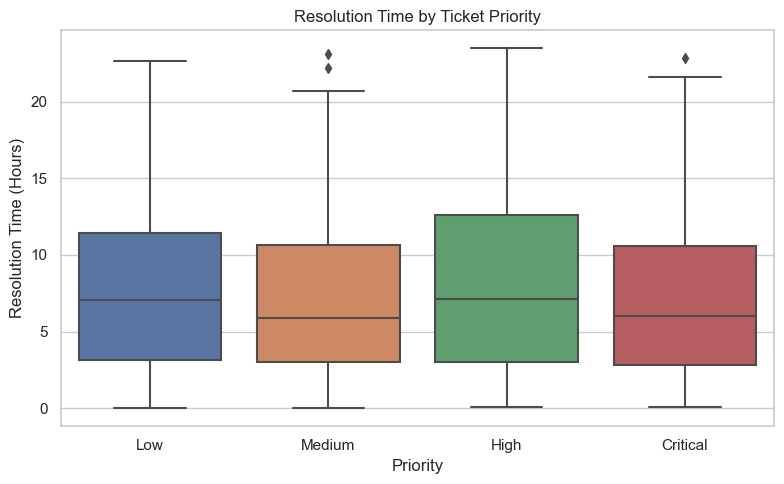

In [50]:
priority_order = ["Low", "Medium", "High", "Critical"]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="ticket_priority",
    y="resolution_time_hours",
    order=priority_order
)
plt.title("Resolution Time by Ticket Priority")
plt.xlabel("Priority")
plt.ylabel("Resolution Time (Hours)")
plt.tight_layout()
plt.show()

In [51]:
effort_summary = (
    df.groupby("high_effort")
      .agg(
          ticket_count=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          avg_satisfaction=("customer_satisfaction_rating", "mean")
      )
)

effort_summary

,ticket_count,avg_resolution_hours,avg_satisfaction
high_effort,,,
False,1053,4.878759,3.046534
True,351,15.675451,2.974359


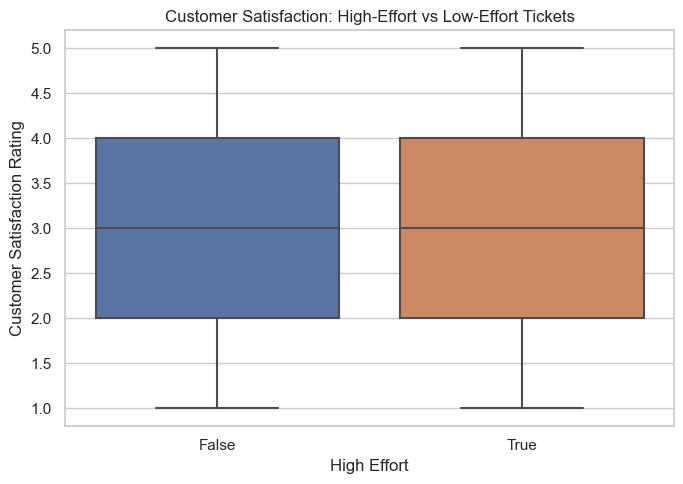

In [52]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="high_effort",
    y="customer_satisfaction_rating"
)
plt.title("Customer Satisfaction: High-Effort vs Low-Effort Tickets")
plt.xlabel("High Effort")
plt.ylabel("Customer Satisfaction Rating")
plt.tight_layout()
plt.show()

In [53]:
top_products = df["product_purchased"].value_counts().head(10).index

product_df = df[df["product_purchased"].isin(top_products)].copy()

product_summary = (
    product_df.groupby("product_purchased")
      .agg(
          ticket_count=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          avg_satisfaction=("customer_satisfaction_rating", "mean")
      )
      .sort_values(by="avg_resolution_hours", ascending=False)
)

product_summary

,ticket_count,avg_resolution_hours,avg_satisfaction
product_purchased,,,
LG OLED,38,9.177193,3.157895
Nest Thermostat,45,8.170370,3.200000
GoPro Hero,42,8.114683,3.476190
Sony Xperia,40,7.752083,2.950000
Amazon Echo,44,7.509470,3.045455
Fitbit Versa Smartwatch,36,7.481944,2.472222
Sony 4K HDR TV,39,7.278632,2.615385
Canon EOS,43,7.133333,3.046512
iPhone,43,6.955039,2.953488


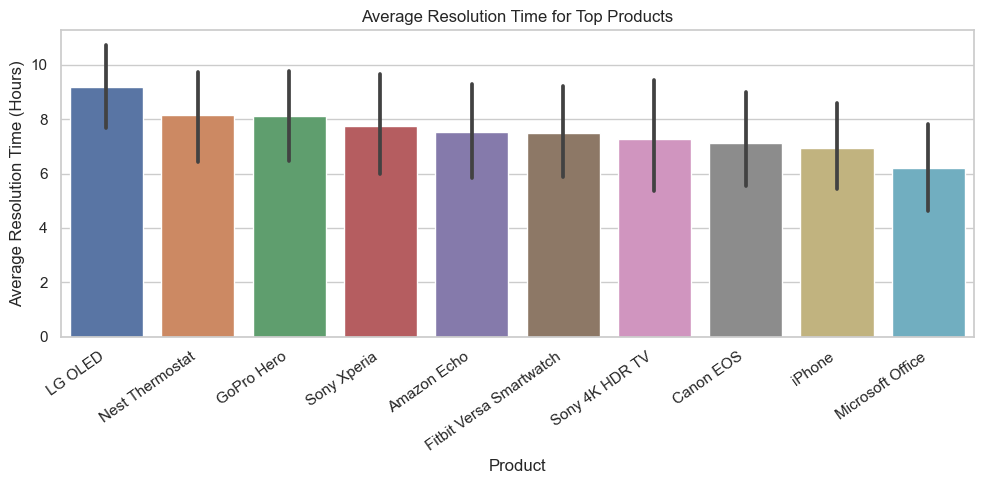

In [54]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=product_df,
    x="product_purchased",
    y="resolution_time_hours",
    estimator=np.mean,
    order=product_summary.index
)
plt.title("Average Resolution Time for Top Products")
plt.xlabel("Product")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [55]:
friction_table = (
    df.groupby("ticket_type_grouped")
      .agg(
          ticket_count=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          avg_response_delay_hours=("response_delay_hours", "mean"),
          avg_satisfaction=("customer_satisfaction_rating", "mean"),
          delay_rate=("is_delayed", "mean"),
          high_effort_rate=("high_effort", "mean")
      )
)

friction_table = friction_table.sort_values(
    by=["delay_rate", "avg_resolution_hours"],
    ascending=False
)

friction_table

,ticket_count,avg_resolution_hours,avg_response_delay_hours,avg_satisfaction,delay_rate,high_effort_rate
ticket_type_grouped,,,,,,
Refund request,304,8.117818,21385.826837,2.898026,0.286184,0.286184
Cancellation request,265,7.693082,21277.112983,3.120755,0.252830,0.252830
Technical issue,305,7.365191,20871.499539,2.891803,0.249180,0.249180
Product inquiry,257,7.676070,21493.340854,3.136187,0.249027,0.249027
Billing inquiry,273,7.010256,21239.555160,3.135531,0.208791,0.208791
